In [1]:
import numpy as np
import pandas as pd

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.6 | numpy 2.5.3


## 1. Pandas Data Structures

| Data Structure | Dimensions | Description |
|---|---|---|
| Series | 1 | 1D labeled homogeneous array, size-immutable |
| DataFrame | 2 | General 2D labeled, size-mutable tabular structure with potentially heterogeneously typed columns |
| Panel | 3 | General 3D labeled, size-mutable array (removed in modern pandas — see note below) |

### 1.1 Series

`pandas.Series(data, index, dtype, copy)` — `data` can be an ndarray, list or constant;
`index` must be unique and hashable (defaults to `np.arange(n)`).

**Object creation** — a Series from a list, letting pandas set the default integer index:

In [2]:
s = pd.Series([1, 3, 5, np.nan, 6, 8])
s

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

**Observation**: because `np.nan` is a float, the whole Series is upcast to `float64`.

For the **Getting** / **Setting** examples we first need a DataFrame with a datetime index:

In [3]:
dates = pd.date_range("20130101", periods=6)
df = pd.DataFrame(np.random.randn(6, 4), index=dates, columns=list("ABCD"))
df

,A,B,C,D
2013-01-01,0.440106,-1.623830,0.658761,1.320885
2013-01-02,0.137428,0.622906,-0.774051,-0.084160
2013-01-03,-1.148058,-1.802877,-0.011564,-0.144229
2013-01-04,-2.283714,0.409896,0.030744,0.260436
2013-01-05,0.812244,0.506845,-1.082313,-0.724227
2013-01-06,0.534430,-1.690651,-1.148563,-0.133159


**Getting** — selecting a single column yields a Series:

In [4]:
df["A"]

2013-01-01    0.440106
2013-01-02    0.137428
2013-01-03   -1.148058
2013-01-04   -2.283714
2013-01-05    0.812244
2013-01-06    0.534430
Freq: D, Name: A, dtype: float64

**Setting** — assigning a Series to a new column aligns it by index automatically:

In [5]:
s1 = pd.Series([1, 2, 3, 4, 5, 6], index=pd.date_range("20130102", periods=6))
s1

2013-01-02    1
2013-01-03    2
2013-01-04    3
2013-01-05    4
2013-01-06    5
2013-01-07    6
Freq: D, dtype: int64

In [6]:
df["F"] = s1
df

,A,B,C,D,F
2013-01-01,0.440106,-1.623830,0.658761,1.320885,NaN
2013-01-02,0.137428,0.622906,-0.774051,-0.084160,1.0
2013-01-03,-1.148058,-1.802877,-0.011564,-0.144229,2.0
2013-01-04,-2.283714,0.409896,0.030744,0.260436,3.0
2013-01-05,0.812244,0.506845,-1.082313,-0.724227,4.0
2013-01-06,0.534430,-1.690651,-1.148563,-0.133159,5.0


**Observation**: `s1` starts on 2013-01-02 while `df` starts on 2013-01-01, so the first row of column `F` is `NaN` — pandas aligns data by index labels, not by position.

### 1.2 DataFrame

`pandas.DataFrame(data, index, columns, dtype, copy)` — `data` can be an ndarray, Series, dict, list or another DataFrame.

In [7]:
data = [['Alex', 10], ['Bob', 12], ['Clarke', 13]]
df2 = pd.DataFrame(data, columns=['Name', 'Age'])
df2

,Name,Age
0,Alex,10
1,Bob,12
2,Clarke,13


### 1.3 Panel (legacy)

The slides show `pd.Panel` for 3D data. **Panel was deprecated in pandas 0.25 and removed in pandas 1.0**, so it cannot run on the pandas 3.x installed here. The modern replacement is a dict of DataFrames (or a MultiIndex DataFrame):

In [8]:
# Modern equivalent of the lecture's Panel example
data = {'Item1': pd.DataFrame(np.random.randn(4, 3)),
        'Item2': pd.DataFrame(np.random.randn(4, 2))}

data['Item1']

,0,1,2
0,0.426544,0.314556,-0.148246
1,-0.998248,0.823477,0.407935
2,-0.295663,0.161073,1.847503
3,1.168951,0.732823,0.238070


**Observation**: like `p['Item1']` on a Panel, `data['Item1']` retrieves a DataFrame of 4 rows × 3 columns. If a true single object is needed, `pd.concat(data)` produces a MultiIndex DataFrame that plays the same role.

## 2. Pivot Table

A pivot table groups data by one or more keys and aggregates the remaining columns (mean by default). Two ways to start: from a DataFrame, or from a file.

### 2.1 Create from DataFrame

In [9]:
# create DataFrame with Team records
dataFrame = pd.DataFrame({
    'Team ID':    {0: 5, 1: 9, 2: 6, 3: 11, 4: 2, 5: 7},
    'Team Name':  {0: 'India', 1: 'Australia', 2: 'Bangladesh',
                   3: 'South Africa', 4: 'Sri Lanka', 5: 'England'},
    'Team Points': {0: 95, 1: 93, 2: 42, 3: 60, 4: 80, 5: 55},
    'Team Rank':  {0: 'One', 1: 'Two', 2: 'Six', 3: 'Four', 4: 'Three', 5: 'Five'}})

print("\n... Pivot ...")
# multiple columns as index
pd.pivot_table(dataFrame, index=['Team ID', 'Team Name', 'Team Rank'])


... Pivot ...


,,,Team Points
Team ID,Team Name,Team Rank,
2,Sri Lanka,Three,80.0
5,India,One,95.0
6,Bangladesh,Six,42.0
7,England,Five,55.0
9,Australia,Two,93.0
11,South Africa,Four,60.0


**Observation**: the only numeric column, `Team Points`, is aggregated (averaged) for each `(Team ID, Team Name, Team Rank)` group — since each group has exactly one row, the values are unchanged.

### 2.2 Create from file

The lecture uses the *sales funnel* sample data (`sales-funnel.xlsx`, from the [Practical Business Python](https://pbpython.com) pivot-table tutorial):

In [10]:
df = pd.read_excel("sales-funnel.xlsx")
df.head()

,Account,Name,Rep,Manager,Product,Quantity,Price,Status
0,714466,Trantow-Barrows,Craig Booker,Debra Henley,CPU,1,30000,presented
1,714466,Trantow-Barrows,Craig Booker,Debra Henley,Software,1,10000,presented
2,714466,Trantow-Barrows,Craig Booker,Debra Henley,Maintenance,2,5000,pending
3,737550,"Fritsch, Russel and Anderson",Craig Booker,Debra Henley,CPU,1,35000,declined
4,146832,Kiehn-Spinka,Daniel Hilton,Debra Henley,CPU,2,65000,won


### 2.3 Pivot the data

In [11]:
pd.pivot_table(df, index=["Name"], values=["Account", "Price", "Quantity"])

,Account,Price,Quantity
Name,,,
Barton LLC,740150.0,35000.0,1.000000
"Fritsch, Russel and Anderson",737550.0,35000.0,1.000000
Herman LLC,141962.0,65000.0,2.000000
Jerde-Hilpert,412290.0,5000.0,2.000000
"Kassulke, Ondricka and Metz",307599.0,7000.0,3.000000
Keeling LLC,688981.0,100000.0,5.000000
Kiehn-Spinka,146832.0,65000.0,2.000000
Koepp Ltd,729833.0,35000.0,2.000000
Kulas Inc,218895.0,25000.0,1.500000


**Note**: the lecture was recorded on an older pandas, which silently averaged only the numeric columns. Modern pandas (2.x/3.x) raises `TypeError: dtype 'str' does not support operation 'mean'` if string columns are left in, so we name the numeric columns explicitly with `values=` — the result is identical to the slide.

Multiple index levels group hierarchically:

In [12]:
pd.pivot_table(df, index=["Name", "Rep", "Manager"], values=["Account", "Price", "Quantity"])

,,,Account,Price,Quantity
Name,Rep,Manager,,,
Barton LLC,John Smith,Debra Henley,740150.0,35000.0,1.000000
"Fritsch, Russel and Anderson",Craig Booker,Debra Henley,737550.0,35000.0,1.000000
Herman LLC,Cedric Moss,Fred Anderson,141962.0,65000.0,2.000000
Jerde-Hilpert,John Smith,Debra Henley,412290.0,5000.0,2.000000
"Kassulke, Ondricka and Metz",Wendy Yule,Fred Anderson,307599.0,7000.0,3.000000
Keeling LLC,Wendy Yule,Fred Anderson,688981.0,100000.0,5.000000
Kiehn-Spinka,Daniel Hilton,Debra Henley,146832.0,65000.0,2.000000
Koepp Ltd,Wendy Yule,Fred Anderson,729833.0,35000.0,2.000000
Kulas Inc,Daniel Hilton,Debra Henley,218895.0,25000.0,1.500000


### 2.4 Index — group and aggregate

`index=["Manager", "Rep"]` answers "how is each sales rep performing under each manager?":

In [13]:
pd.pivot_table(df, index=["Manager", "Rep"], values=["Account", "Price", "Quantity"])

Account         Price  Quantity
Manager       Rep                                            
Debra Henley  Craig Booker   720237.0  20000.000000  1.250000
              Daniel Hilton  194874.0  38333.333333  1.666667
              John Smith     576220.0  20000.000000  1.500000
Fred Anderson Cedric Moss    196016.5  27500.000000  1.250000
              Wendy Yule     614061.5  44250.000000  3.000000

### 2.5 Index — identify values column

The `Price` column is automatically averaged; restrict the aggregation to it with `values=`:

In [14]:
pd.pivot_table(df, index=["Manager", "Rep"], values=["Price"])

Price
Manager       Rep                        
Debra Henley  Craig Booker   20000.000000
              Daniel Hilton  38333.333333
              John Smith     20000.000000
Fred Anderson Cedric Moss    27500.000000
              Wendy Yule     44250.000000

### 2.6 Aggregate with `aggfunc`

Instead of the mean, take a **sum** with `np.sum`:

In [15]:
pd.pivot_table(df, index=["Manager", "Rep"], values=["Price"], aggfunc=np.sum)

Price
Manager       Rep                  
Debra Henley  Craig Booker    80000
              Daniel Hilton  115000
              John Smith      40000
Fred Anderson Cedric Moss    110000
              Wendy Yule     177000

`aggfunc` can take a **list of functions** — a mean via `np.mean` plus a count via `len`:

In [16]:
pd.pivot_table(df, index=["Manager", "Rep"], values=["Price"], aggfunc=[np.mean, len])

mean   len
                                    Price Price
Manager       Rep                              
Debra Henley  Craig Booker   20000.000000     4
              Daniel Hilton  38333.333333     3
              John Smith     20000.000000     2
Fred Anderson Cedric Moss    27500.000000     4
              Wendy Yule     44250.000000     4

**Observation**: Craig Booker closed 4 deals averaging 20,000 (total 80,000), while Wendy Yule's 4 deals average 44,250 — the count column from `len` makes it clear the averages are computed over very different sample sizes.

## 3. Time Series

### 3.1 Date / Time parsing

`pd.to_datetime` converts strings to pandas `Timestamp` objects:

In [17]:
pd.to_datetime('2018-01-15 3:45pm')

Timestamp('2018-01-15 15:45:00')

In [18]:
pd.to_datetime('7/8/1952')

Timestamp('1952-07-08 00:00:00')

It also parses whole arrays, with an explicit `format` when the layout is ambiguous:

In [19]:
pd.to_datetime(['2/25/10', '8/6/17', '12/15/12'], format='%m/%d/%y')

DatetimeIndex(['2010-02-25', '2017-08-06', '2012-12-15'], dtype='datetime64[us]', freq=None)

### 3.2 Example — OPSD Germany daily power data

The lecture uses `opsd_germany_daily.csv` (Open Power System Data, daily electricity consumption/production in Germany, 2006–2017):

In [20]:
opsd_daily = pd.read_csv('opsd_germany_daily.csv')
opsd_daily.shape

(4383, 5)

4383 rows, 5 columns. Check the data types:

In [21]:
opsd_daily.dtypes

Date               str
Consumption    float64
Wind           float64
Solar          float64
Wind+Solar     float64
dtype: object

`Date` is read as a string (`str`); convert it to `datetime64` so time-based operations become available:

In [22]:
opsd_daily['Date'] = pd.to_datetime(opsd_daily['Date'])
opsd_daily.dtypes

Date           datetime64[us]
Consumption           float64
Wind                  float64
Solar                 float64
Wind+Solar            float64
dtype: object

### 3.3 Index

In [23]:
opsd_daily = opsd_daily.set_index('Date')
opsd_daily.index

DatetimeIndex(['2006-01-01', '2006-01-02', '2006-01-03', '2006-01-04',
               '2006-01-05', '2006-01-06', '2006-01-07', '2006-01-08',
               '2006-01-09', '2006-01-10',
               ...
               '2017-12-22', '2017-12-23', '2017-12-24', '2017-12-25',
               '2017-12-26', '2017-12-27', '2017-12-28', '2017-12-29',
               '2017-12-30', '2017-12-31'],
              dtype='datetime64[us]', name='Date', length=4383, freq=None)

In [24]:
opsd_daily.head(3)

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,1069.184,NaN,NaN,NaN
2006-01-02,1380.521,NaN,NaN,NaN
2006-01-03,1442.533,NaN,NaN,NaN


### 3.4 Use the index

Add columns with year, month and weekday name extracted from the DatetimeIndex
(the slides use `.index.weekday_name`, which was removed from pandas — the modern equivalent is `.index.day_name()`):

In [25]:
# Add columns with year, month, and weekday name
opsd_daily['Year'] = opsd_daily.index.year
opsd_daily['Month'] = opsd_daily.index.month
opsd_daily['Weekday Name'] = opsd_daily.index.day_name()
opsd_daily.head(3)

,Consumption,Wind,Solar,Wind+Solar,Year,Month,Weekday Name
Date,,,,,,,
2006-01-01,1069.184,NaN,NaN,NaN,2006,1,Sunday
2006-01-02,1380.521,NaN,NaN,NaN,2006,1,Monday
2006-01-03,1442.533,NaN,NaN,NaN,2006,1,Tuesday


### 3.5 Time-based indexing — select a row

In [26]:
opsd_daily.loc['2017-08-10']

Consumption     1351.491
Wind             100.274
Solar              71.16
Wind+Solar       171.434
Year                2017
Month                  8
Weekday Name    Thursday
Name: 2017-08-10 00:00:00, dtype: object

Or a slice of days, using partial date strings:

In [27]:
opsd_daily.loc['2014-01-20':'2014-01-22']

,Consumption,Wind,Solar,Wind+Solar,Year,Month,Weekday Name
Date,,,,,,,
2014-01-20,1590.687,78.647,6.371,85.018,2014,1,Monday
2014-01-21,1624.806,15.643,5.835,21.478,2014,1,Tuesday
2014-01-22,1625.155,60.259,11.992,72.251,2014,1,Wednesday


### 3.6 Visualization

In [28]:
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
# Use seaborn style defaults and set the default figure size
sns.set(rc={'figure.figsize': (11, 4)})

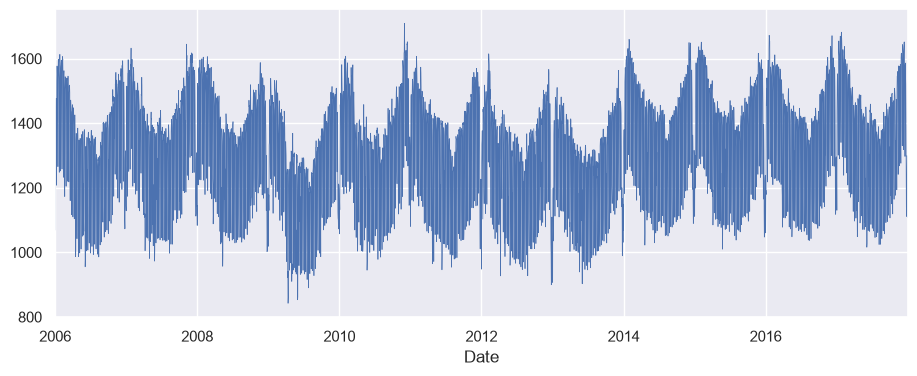

In [29]:
opsd_daily['Consumption'].plot(linewidth=0.5);

**Observation**: electricity consumption shows a strong yearly seasonality (winter peaks, summer troughs) on top of a fairly stable level around 1,200–1,400 GWh.

### 3.7 Advanced usage — resampling & rolling windows

The slides list *frequencies, resampling, rolling windows, trend, seasonality* as advanced topics. Two quick demonstrations:

- **Resampling** aggregates the daily series to a lower frequency (monthly mean here):


In [30]:
opsd_monthly = opsd_daily['Consumption'].resample('ME').mean()
opsd_monthly.head()

Date
2006-01-31    1461.442065
2006-02-28    1467.106893
2006-03-31    1418.649161
2006-04-30    1275.058900
2006-05-31    1253.488484
Freq: ME, Name: Consumption, dtype: float64

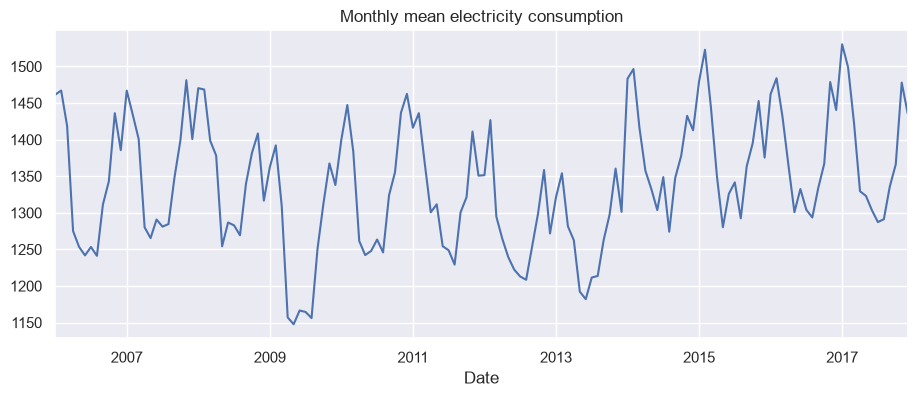

In [31]:
opsd_monthly.plot(linewidth=1.5, title='Monthly mean electricity consumption');

- **Rolling windows** smooth the series; a 7-day rolling mean removes the weekly pattern:

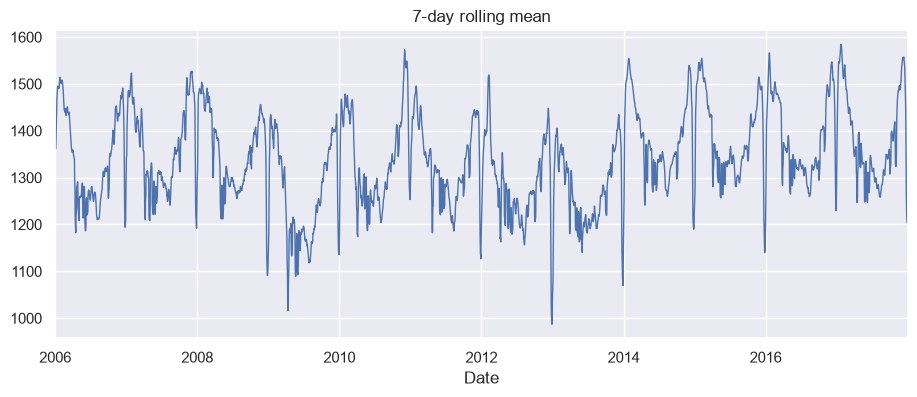

In [32]:
opsd_daily['Consumption'].rolling(7, center=True).mean().plot(linewidth=1, title='7-day rolling mean');

## 4. High Performance Pandas

`pd.eval()` and `DataFrame.query()` evaluate expressions as strings using the `numexpr` engine, which avoids large temporary arrays — faster and less memory-hungry than the equivalent Python operators.

### 4.1 Example setup

Four large DataFrames (100,000 × 100 each):

In [33]:
nrows, ncols = 100000, 100
rng = np.random.RandomState(42)
df1, df2, df3, df4 = (pd.DataFrame(rng.rand(nrows, ncols))
                      for i in range(4))

To compute the sum of all four DataFrames with the typical Pandas approach, we can just write the sum:

In [34]:
%timeit df1 + df2 + df3 + df4

3.01 ms ± 34.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### 4.2 `eval()`

The same result computed via `pd.eval` by constructing the expression as a string:

In [35]:
%timeit pd.eval('df1 + df2 + df3 + df4')

3.32 ms ± 48.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


The `eval()` version computes the same result:

In [36]:
np.allclose(df1 + df2 + df3 + df4,
            pd.eval('df1 + df2 + df3 + df4'))

True

**Observation**: the lecture (recorded on older hardware and pandas 0.x) measured `eval()` about 50% faster. On this machine the two timings are nearly equal — modern Apple-silicon memory bandwidth is so high that even the naive sum is bandwidth-bound, leaving little room to win. The lasting advantage of `eval()` is **memory**: `df1 + df2 + df3 + df4` allocates a full-size temporary per `+` (three 80 MB frames here), while `eval()` evaluates the whole expression in one pass with a single output buffer — which is what keeps very large workloads from running out of RAM.

### 4.3 `query()`

`DataFrame.query()` applies the same idea to filtering. The lecture example uses columns named `A` and `B`, so build a suitably named frame first:

In [37]:
df5 = pd.DataFrame(rng.rand(1000000, 2), columns=['A', 'B'])
df5.head()

,A,B
0,0.615875,0.525167
1,0.047354,0.330858
2,0.412879,0.441564
3,0.689047,0.559068
4,0.230350,0.290486


Boolean indexing first:

In [38]:
result1 = df5[(df5.A < 0.5) & (df5.B < 0.5)]
result1.shape

(250438, 2)

This filtering expression *cannot* be written with `pd.eval` directly, but `query()` handles it:

In [39]:
result2 = df5.query('A < 0.5 and B < 0.5')
np.allclose(result1.values, result2.values)

True

**Observation**: both approaches return the same rows; `query()` expresses the filter in a readable string and avoids creating the intermediate boolean-mask arrays, which pays off on large frames.

## Summary

- **Series / DataFrame** are the core 1D/2D labeled containers; Panel is gone, use a dict of DataFrames or a MultiIndex instead.
- **`pd.pivot_table`** groups by `index`, aggregates `values` with `aggfunc` (mean by default; lists of functions allowed).
- **Time series**: parse with `pd.to_datetime`, `set_index` to a DatetimeIndex, slice with date strings, then resample / roll / plot.
- **High performance**: `pd.eval()` for arithmetic between frames, `df.query()` for row filtering — both faster and more memory-efficient.